In [1]:
import torch
import gym
from gym import spaces
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict, deque
from typing import Dict, List, Tuple
from torch.utils.tensorboard import SummaryWriter
import argparse
from replay_buffer import ReplayBuffer
from maddpg import MADDPG
from matd3 import MATD3
import copy
from PrioritizedReplayBuffer import PrioritizedReplayBuffer # <-- 导入新的
import warnings
import os
import gymnasium
warnings.filterwarnings("ignore", category=UserWarning)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
class EnergyStorageEnv(gym.Env):
    def __init__(self, num_agents, episode_length, future_price, battery_capacity, max_charge_rate,future_load, w_pv_rolling, data_path=None, mode='train'):
        # --- 核心属性 ---
        self.num_agents = num_agents
        self.episode_length = episode_length
        self.future_price = future_price
        self.future_load = future_load
        self.w_pv_rolling = w_pv_rolling #滚动峰谷差奖励的权重
        self.mode = mode
        self.n = self.num_agents
        
        # --- 储能相关参数 ---
        self.battery_capacity = battery_capacity
        self.max_charge_rate = max_charge_rate
        self.efficiency = 1  # 充放电效率为0.95
        self.init_soc = 0.05
        
        # --- 数据加载与处理 ---
        if data_path is None:
            data_path = Path.cwd().parent / "data" / "train_prices.csv"
        self.raw_data = self._load_data(data_path)

       # 计算全局负荷标准化参数
        load_cols = [f"load{i+1}" for i in range(self.num_agents)]
        all_loads = self.raw_data[load_cols].values.flatten()
        self.load_norm_params = {'mean': np.mean(all_loads), 'std': np.std(all_loads)}
        self.num_available_episodes = (len(self.raw_data) // self.episode_length) - 1

        # --- 状态与历史记录 ---
        self.current_step = 0
        self.battery_soc = {}
        self.load_profiles = {}
        self.net_load_history = deque(maxlen=96)
        # --- Gym 接口 ---
        self.observation_space = self._create_observation_space()
        self.action_space = self._create_action_space()
        # 初始化状态
        self.reset()

    def _create_observation_space(self) -> List[spaces.Box]:
        obs_shape = (5 + self.future_price + self.future_load,)
        return [spaces.Box(low=-np.inf, high=np.inf, shape=obs_shape, dtype=np.float32) for _ in range(self.n)]

    def _create_action_space(self) -> List[spaces.Box]:
        return [spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32) for _ in range(self.n)]
    
    def _load_data(self, data_path: str) -> pd.DataFrame:
        try:
            return pd.read_csv(data_path)
        except Exception as e:
            raise ValueError(f"Unable to load data file: {e}")
       
    def _get_single_observation(self, agent_id: int) -> np.ndarray:
        time_sin = np.sin(2 * np.pi * self.current_step / self.episode_length)
        time_cos = np.cos(2 * np.pi * self.current_step / self.episode_length)
        
        profile = self.load_profiles[agent_id]
        current_price = profile['price'].iloc[self.current_step]
        current_load = profile['load'].iloc[self.current_step]
        current_soc = self.battery_soc[agent_id]
        
        # 为未来观测准备数据，如果到达末尾则用0填充
        future_prices = profile['price'].iloc[self.current_step + 1 : self.current_step + 1 + self.future_price].values
        future_loads = profile['load'].iloc[self.current_step + 1 : self.current_step + 1 + self.future_load].values
        
        padded_prices = np.pad(future_prices, (0, self.future_price - len(future_prices)), 'constant')
        padded_loads = np.pad(future_loads, (0, self.future_load - len(future_loads)), 'constant')

        obs = np.concatenate([
            [time_sin, time_cos, current_price, current_load, current_soc],
            padded_prices,
            padded_loads
        ]).astype(np.float32)
        return obs

    def reset(self, episode_idx=None) -> List[np.ndarray]:
        """重置环境。如果提供了episode_idx，则用于测试模式。"""
        self.current_step = 0
        self.battery_soc = {i: self.init_soc for i in range(self.n)}
        self.net_load_history.clear()

        if episode_idx is None:
            # 训练模式：随机选择一天（确保有前一天的数据）
            day_idx = np.random.randint(1, self.num_available_episodes + 1)
        else:
            # 测试模式：使用指定索引（确保有前一天的数据）
            day_idx = episode_idx + 1
            if day_idx > self.num_available_episodes:
                raise IndexError(f"Test episode_idx {episode_idx} is out of valid range.")

        # --- 计算电价标准化参数 (基于前一天) ---
        prev_day_start = (day_idx - 1) * self.episode_length
        prev_day_end = prev_day_start + 2*self.episode_length
        prev_day_prices = self.raw_data['price'].iloc[prev_day_start:prev_day_end].values
        self.episode_price_mean = np.mean(prev_day_prices)
        self.episode_price_std = np.std(prev_day_prices)
        if self.episode_price_std == 0: self.episode_price_std = 1

        # --- 准备当前回合的数据 ---
        start = day_idx * self.episode_length
        end = start + self.episode_length
        
        episode_prices = self.raw_data['price'].iloc[start:end].values
        normalized_prices = (episode_prices - self.episode_price_mean) / self.episode_price_std
        
        load_cols = [f"load{i+1}" for i in range(self.num_agents)]
        for agent_id in range(self.n):
            agent_load = self.raw_data[load_cols[agent_id]].iloc[start:end].values
            normalized_load = (agent_load - self.load_norm_params['mean']) / self.load_norm_params['std']
            self.load_profiles[agent_id] = pd.DataFrame({'load': normalized_load, 'price': normalized_prices})
        
        # 初始化前一天的总负荷历史用于削峰填谷奖励计算
        prev_day_total_load = self.raw_data[load_cols].iloc[prev_day_start:prev_day_end].sum(axis=1).values
        self.net_load_history.extend(prev_day_total_load)

        return [self._get_single_observation(i) for i in range(self.n)]
    
    def step(self, actions: List[np.ndarray]) -> Tuple[List[np.ndarray], List[float], List[bool], Dict]:
        """执行一个时间步的环境动态"""
        # [MODIFIED] 兼容Runner: 将输入的动作列表转换为字典
        actions_dict = {i: action[0] for i, action in enumerate(actions)}
        current_price_normalized = self.load_profiles[0]['price'].iloc[self.current_step]
        real_price = current_price_normalized * self.episode_price_std + self.episode_price_mean

        rewards, ess_power = {}, {}
        total_ess_power, total_economic_reward, total_soc_penalty = 0, 0, 0

        for agent_id, action_val in actions_dict.items():
            # 动作值在[-1, 1]之间，映射到[-max_rate, max_rate]
            charge_power = action_val * self.max_charge_rate
            delta_soc = (charge_power * self.efficiency if charge_power >= 0 else charge_power / self.efficiency) / self.battery_capacity
            new_soc = self.battery_soc[agent_id] + delta_soc

            # 初始化越限惩罚项
            soc_penalty = 0.0
            if new_soc > 0.95:
                soc_penalty = -5.0 if action_val > 0 else 0
                charge_power = min(charge_power, ((0.95 - self.battery_soc[agent_id]) * self.battery_capacity) / self.efficiency)
                new_soc = 0.95
            elif new_soc < 0.05:
                soc_penalty = -5.0 if action_val < 0 else 0
                charge_power = max(charge_power, -((self.battery_soc[agent_id] - 0.05) * self.battery_capacity * self.efficiency))
                new_soc = 0.05

            self.battery_soc[agent_id] = new_soc
            ess_power[agent_id] = charge_power
            total_ess_power += charge_power
            total_soc_penalty += soc_penalty

            # 计算奖励
            # 当充电时，经济收益为负；当放电时，经济收益为正
            economic_reward = -charge_power * real_price
            total_economic_reward += economic_reward
            rewards[agent_id] = economic_reward + soc_penalty

        # --- 计算协同奖励 ---
        # 1. 计算当前时间步的真实原始总负荷
        original_total_load = 0
        for agent_id in range(self.num_agents):
            normalized_load = self.load_profiles[agent_id]['load'].iloc[self.current_step]
            real_load = normalized_load * self.load_norm_params['std'] + self.load_norm_params['mean']
            original_total_load += real_load
        # 2. 计算净总负荷
        net_total_load = original_total_load + total_ess_power
        self.net_load_history.append(net_total_load)
        
        # 3. 计算滚动峰谷差协同奖励
        peak_valley_penalty = 0
        if self.w_pv_rolling > 0 and len(self.net_load_history) > 1:
            peak_valley_penalty = -self.w_pv_rolling * np.std(self.net_load_history)
            for agent_id in range(self.n):
                rewards[agent_id] += peak_valley_penalty / self.n


        self.current_step += 1
        
        # 检查episode是否结束
        done = self.current_step >= self.episode_length
        
        obs_n = [self._get_single_observation(i) for i in range(self.n)] if not done else [np.zeros_like(self.observation_space[i].low) for i in range(self.n)]
        reward_n = [rewards[i] for i in range(self.n)]
        done_n = [done] * self.n
      
        # 将需要记录的内部状态放入info字典
        info = {
            'ess_power': ess_power, 'soc': self.battery_soc, 'price': real_price,
            'original_total_load': original_total_load, 'net_total_load': net_total_load,
            'original_load_cost': original_total_load * real_price,
            'cost_with_ess': net_total_load * real_price,
            'ess_profit': total_economic_reward, 'soc_penalty': total_soc_penalty,
            'peak_valley_penalty': peak_valley_penalty
        }
        return obs_n, reward_n, done_n, info

    def close(self):
        pass

In [3]:
class Runner:   # 定义一个名为 Runner 的类，它封装了整个训练和评估的流程
    def __init__(self, args, env_name, number, seed): # Runner 类的构造函数，用于初始化训练设置
        self.args = args # 保存所有通过 argparse 解析的参数
        self.env_name = env_name
        self.number = number
        self.seed = seed
        # Create env
        env_params = {
            'num_agents': args.num_agents,
            'episode_length': args.episode_limit,
            'future_price': args.future_price,
            'battery_capacity': args.battery_capacity,
            'max_charge_rate': args.max_charge_rate,
            'future_load': args.future_load,
            'w_pv_rolling': args.w_pv_rolling
        }
        self.env = EnergyStorageEnv(**env_params)  # 创建用于训练的环境实例，指定为连续动作空间
        self.env_evaluate = EnergyStorageEnv(**env_params)# 创建一个独立的环境实例用于评估策略
        print("--- Normalization Parameters ---")
        print("--- Normalization Parameters (from training data) ---")
        print(f"  Load Mean: {self.env.load_norm_params['mean']:.4f}")
        print(f"  Load Std: {self.env.load_norm_params['std']:.4f}")
        print("  (Price normalization is calculated per episode based on the previous day)")
        print("----------------------------------------------------")
        self.args.N = self.env.n  # The number of agents
        self.args.obs_dim_n = [self.env.observation_space[i].shape[0] for i in range(self.args.N)]  # obs dimensions of N agents
        self.args.action_dim_n = [self.env.action_space[i].shape[0] for i in range(self.args.N)]  # actions dimensions of N agents
        print("observation_space=", self.env.observation_space)
        print("obs_dim_n={}".format(self.args.obs_dim_n))
        print("action_space=", self.env.action_space)
        print("action_dim_n={}".format(self.args.action_dim_n))

        # Set random seed
        np.random.seed(self.seed)
        torch.manual_seed(self.seed) # 为 PyTorch 设置随机种子，以确保网络初始化和训练过程的可复现性

        # Create N agents
        if self.args.algorithm == "MADDPG":
            print("Algorithm: MADDPG")
            self.agent_n = [MADDPG(args, agent_id) for agent_id in range(args.N)]
        elif self.args.algorithm == "MATD3":
            print("Algorithm: MATD3")
            self.agent_n = [MATD3(args, agent_id) for agent_id in range(args.N)]
        else:
            print("Wrong!!!")

        self.replay_buffer = ReplayBuffer(self.args) # 根据参数创建一个经验回放缓冲区实例
        # self.replay_buffer = PrioritizedReplayBuffer(self.args) # <-- 使用奖励更高的优先采样
        # Create a tensorboard,# 创建一个 SummaryWriter 实例，用于记录训练日志，日志文件会保存在指定的目录结构下
        self.writer = SummaryWriter(log_dir='runs/{}/{}_env_{}_number_{}_seed_{}'.format(self.args.algorithm, self.args.algorithm, self.env_name, self.number, self.seed))
        self.evaluate_rewards = []  # 初始化一个空列表，用于记录每次评估的平均奖励
        self.episode_rewards = []  # 用于记录每个训练回合的奖励
        self.history = []  # 新增：用于存储每一代的详细历史数据
        self.total_steps = 0

        self.noise_std = self.args.noise_std_init   # 初始化用于动作探索的高斯噪声的标准差

    def save_model(self, model_dir, episode):
        # 在模型目录中为特定算法创建一个子目录
        algo_model_dir = os.path.join(model_dir, self.args.algorithm)
        if not os.path.exists(algo_model_dir):
            os.makedirs(algo_model_dir)
        for agent in self.agent_n:
            # 调用时不传递 agent_id，因为它已在 agent 内部定义
            agent.save_model(algo_model_dir, episode)
        print(f"Models saved to {algo_model_dir}")

    def load_model(self, model_dir, episode):
        # 从特定算法的子目录加载模型
        algo_model_dir = os.path.join(model_dir, self.args.algorithm)
        for agent in self.agent_n:
            agent.load_model(algo_model_dir, episode)
        print(f"Models loaded from {algo_model_dir}")

    def run(self, ):
        episode_num = 0
        while self.total_steps < self.args.max_train_steps:
            #--------------------重置环境---------------------
            obs_n = self.env.reset() # 重置环境，开始一个新的 episode，并获取初始观测
            episode_reward = 0  # 初始化当前训练回合的奖励
            episode_actions_history = [[] for _ in range(self.args.N)]
            episode_soc_history = [[] for _ in range(self.args.N)]
            episode_price_history = []
            episode_original_load_history = [] 
            episode_net_load_history = []
            episode_original_load_cost_history = []
            episode_ess_profit_history = []
            episode_soc_penalty_history = []
            episode_peak_valley_penalty_history = []
            episode_cost_with_ess_history = []
            for i in range(self.args.N): # 记录初始SOC
                episode_soc_history[i].append(self.env.battery_soc[i])

            for _ in range(self.args.episode_limit):
                # 每个智能体根据自己的局部观测选择动作，并加入噪声以进行探索
                a_n = [agent.choose_action(obs, noise_std=self.noise_std) for agent, obs in zip(self.agent_n, obs_n)]
                # --------------------------!!!注意！！！这里一定要deepcopy，MPE环境会把a_n乘5-------------------------------------------
                obs_next_n, r_n, done_n, info = self.env.step(copy.deepcopy(a_n))# 将动作列表传入环境，执行一步，并获取返回的下一个观测、奖励、完成标志等
                episode_reward += sum(r_n) # 累加当前步所有智能体的奖励

                #-----------------记录-----------------
                episode_price_history.append(info['price'])
                episode_original_load_history.append(info['original_total_load']) 
                episode_net_load_history.append(info['net_total_load'])  
                episode_original_load_cost_history.append(info['original_load_cost'])
                episode_ess_profit_history.append(info['ess_profit'])
                episode_soc_penalty_history.append(info['soc_penalty'])
                episode_peak_valley_penalty_history.append(info['peak_valley_penalty'])
                episode_cost_with_ess_history.append(info['cost_with_ess'])
                for i in range(self.args.N):
                    episode_actions_history[i].append(info['ess_power'][i])
                    episode_soc_history[i].append(info['soc'][i])

                if episode_num % 50 < 1:
                    print(f"--- Episode: {episode_num + 1}, Step: {self.total_steps} ---")
                    # 打印第一个智能体的观测值、动作和奖励
                    print(f"  Obs (Agent 0): {obs_n[0]}")
                    print(f"  Action (Agent 0): {a_n[0]}")
                    print(f"  Reward (Agent 0): {r_n[0]}")
                    print("-" * 20)

                # Store the transition
                self.replay_buffer.store_transition(obs_n, a_n, r_n, obs_next_n, done_n) # 将这个(s, a, r, s')的转换经验存储到回放缓冲区
                obs_n = obs_next_n # 更新当前观测，为下一步做准备
                self.total_steps += 1

                # Decay noise_std
                if self.args.use_noise_decay: # 如果启用了噪声衰减
                    # 线性衰减噪声标准差，直到达到设定的最小值
                    self.noise_std = self.noise_std - self.args.noise_std_decay if self.noise_std - self.args.noise_std_decay > self.args.noise_std_min else self.args.noise_std_min

                if self.replay_buffer.current_size > self.args.batch_size: # 当缓冲区中的经验数量足够一个批次时
                    # Train each agent individually
                    for agent_id in range(self.args.N): 
                        self.agent_n[agent_id].train(self.replay_buffer, self.agent_n) # 对每个智能体进行一次训练

                if all(done_n):
                    break

            episode_num += 1
            self.history.append({
                'actions': episode_actions_history,
                'soc': episode_soc_history,
                'price': episode_price_history,
                'original_load': episode_original_load_history, 
                'net_load': episode_net_load_history,
                'original_load_cost': episode_original_load_cost_history,
                'ess_profit': episode_ess_profit_history,
                'soc_penalty': episode_soc_penalty_history,
                'peak_valley_penalty': episode_peak_valley_penalty_history,
                'cost_with_ess': episode_cost_with_ess_history
            })
            self.episode_rewards.append(episode_reward)
            avg_reward = np.mean(self.episode_rewards[-50:]) if len(self.episode_rewards) >= 50 else np.mean(self.episode_rewards) # 计算最近100个回合的平均奖励，如果不足100个则计算所有回合的平均奖励
            # 打印每个训练回合的结果
            print(f"Episode: {episode_num}, Total Steps: {self.total_steps}, Reward: {episode_reward:.2f}, Avg Reward: {avg_reward:.2f}")
            # 将训练回合的奖励也记录到 TensorBoard
            self.writer.add_scalar('train_episode_rewards_{}'.format(self.env_name), episode_reward, global_step=self.total_steps)
            self.writer.add_scalar('avg_episode_rewards_{}'.format(self.env_name), avg_reward, global_step=self.total_steps)
        self.env.close()
        self.env_evaluate.close()


In [4]:
if __name__ == '__main__':

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("="*40)
    print(f"Running on device: {device}")
    print("="*40)
    
    TrainEpisode = 500  # 训练的总回合数
    STEP=96
    parser = argparse.ArgumentParser("Hyperparameters Setting for MADDPG and MATD3 in MPE environment")
    # --- 环境相关参数 ---
    parser.add_argument("--num_agents", type=int, default=3, help="Number of agents")
    parser.add_argument("--future_price", type=int, default=24, help="Number of future price steps to observe")
    parser.add_argument("--future_load", type=int, default=24, help="Number of future load steps to observe")
    parser.add_argument("--battery_capacity", type=float, default=1, help="Capacity of the battery (kWh)")
    parser.add_argument("--max_charge_rate", type=float, default=0.1, help="Max charge/discharge rate of the battery (kW)")
    parser.add_argument("--w_pv_rolling", type=float, default=1, help="Weight for rolling peak-valley difference reward")

    # --- 训练相关参数 ---
    parser.add_argument("--algorithm", type=str, default="MATD3", help="MADDPG or MATD3")
    parser.add_argument("--episode_limit", type=int, default=STEP, help="Maximum number of steps per episode")
    parser.add_argument("--max_train_steps", type=int, default=int(TrainEpisode*STEP), help=" Maximum number of training steps")
    parser.add_argument("--batch_size", type=int, default=STEP*10, help="Batch size")
    parser.add_argument("--evaluate_freq", type=float, default=100, help="Evaluate the policy every 'evaluate_freq' steps")
    parser.add_argument("--evaluate_times", type=float, default=3, help="Evaluate times")
    parser.add_argument("--max_action", type=float, default=1.0, help="Max action")

    parser.add_argument("--buffer_size", type=int, default=int(1e6), help="The capacity of the replay buffer")
    parser.add_argument("--hidden_dim", type=int, default=128, help="The number of neurons in hidden layers of the neural network")
    parser.add_argument("--noise_std_init", type=float, default=0.2*2, help="The std of Gaussian noise for exploration")
    parser.add_argument("--noise_std_min", type=float, default=0.1*2, help="The std of Gaussian noise for exploration")
    parser.add_argument("--noise_decay_steps", type=float, default=3e5, help="How many steps before the noise_std decays to the minimum")
    parser.add_argument("--use_noise_decay", type=bool, default=True, help="Whether to decay the noise_std")
    parser.add_argument("--lr_a", type=float, default=1e-4, help="Learning rate of actor")
    parser.add_argument("--lr_c", type=float, default=1e-4, help="Learning rate of critic")
    parser.add_argument("--gamma", type=float, default=0.999, help="Discount factor")
    parser.add_argument("--tau", type=float, default=0.01, help="Softly update the target network")
    parser.add_argument("--use_orthogonal_init", type=bool, default=True, help="Orthogonal initialization")
    parser.add_argument("--use_grad_clip", type=bool, default=True, help="Gradient clip")
    parser.add_argument("--policy_update_freq", type=int, default=2, help="The frequency of policy updates")
    # --------------------------------------MATD3--------------------------------------------------------------------
    parser.add_argument("--policy_noise", type=float, default=0.2, help="Target policy smoothing")
    parser.add_argument("--noise_clip", type=float, default=0.5, help="Clip noise")

    args = parser.parse_args(args=[])
    args.device = device
    args.noise_std_decay = (args.noise_std_init - args.noise_std_min) / args.noise_decay_steps

    env_name = "EnergyStorage"
    runner = Runner(args, env_name=env_name, number=1, seed=0)
    runner.run()

    # 在训练结束后保存最终模型
    # 定义模型保存目录
    model_save_dir = "./saved_models"
    final_episode = TrainEpisode
    runner.save_model(model_save_dir, final_episode)


Running on device: cuda
--- Normalization Parameters ---
--- Normalization Parameters (from training data) ---
  Load Mean: 0.1093
  Load Std: 0.1363
  (Price normalization is calculated per episode based on the previous day)
----------------------------------------------------
observation_space= [Box(-inf, inf, (53,), float32), Box(-inf, inf, (53,), float32), Box(-inf, inf, (53,), float32)]
obs_dim_n=[53, 53, 53]
action_space= [Box(-1.0, 1.0, (1,), float32), Box(-1.0, 1.0, (1,), float32), Box(-1.0, 1.0, (1,), float32)]
action_dim_n=[1, 1, 1]
Algorithm: MATD3
------use_orthogonal_init------
------use_orthogonal_init------


------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
--- Episode: 1, Step: 0 ---
  Obs (Agent 0): [0.         1.         0.5974258  0.0345828  0.05       0.5974258
 0.8612981  0.8612981  0.8612981  0.8612981  2.0352983  2.0352983
 2.0352983  2.0352983  2.3139846  2.3139846  2.3139846  2.3139846
 1.3908944  1.3908944  1.3908944  1.3908944  0.8335221  0.8335221
 0.8335221  0.8335221  0.26411343 0.26411343 0.26411343 0.19596973
 0.40870705 0.48206472 0.44538587 0.43805012 0.665459   0.48206472
 0.2986705  0.33534935 0.23264858 0.40870705 2.0519195  2.9028685
 0.7388167  0.665459   3.717139   0.84151745 0.3720282  0.7094736
 0.6581232  0.3720282  0.6287801  0.07859742 0.07859742]
  Action (Agent 0): [0.57175785]
  Reward (Agent 0): -2.1405830675261335
--------------------
--- Episode: 1, Step: 1 ---
  Obs (Agent 0): [0.06540313 0.99785894 0.5974258  0.19596973 0.10717578 0.8612981
 0.8612981  0.8612981  0.8612981  2

--- Plotting Training Process Analysis ---


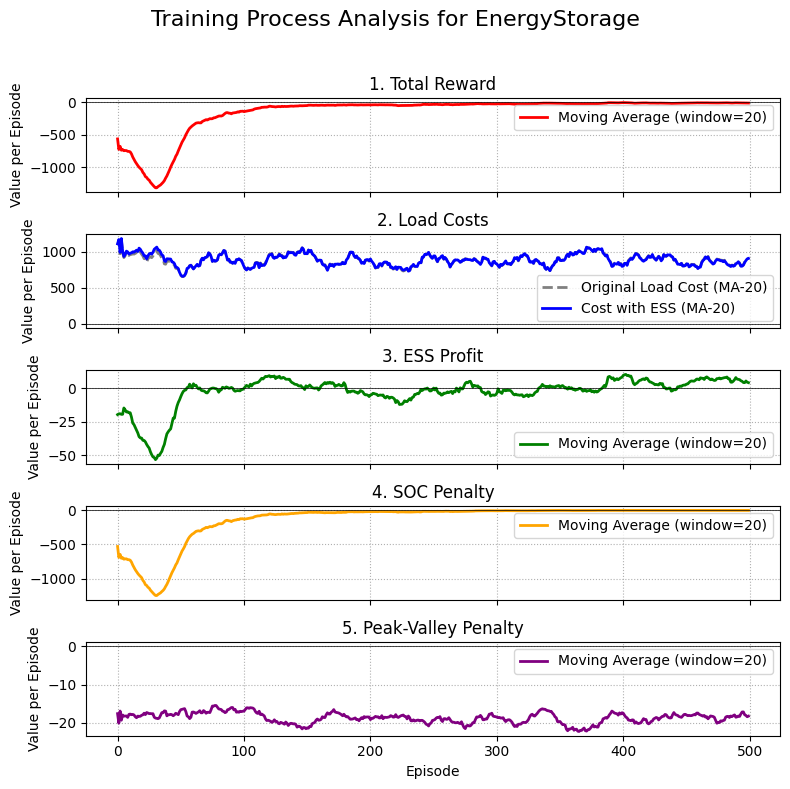

In [5]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import pandas as pd
import numpy as np

# --- 1. Plot Training Process Analysis (5 separate subplots) ---
print("--- Plotting Training Process Analysis ---")

# --- Data Aggregation ---
# Extract the sum of each metric per episode from history
ep_original_load_cost = [np.sum(ep_data['original_load_cost']) for ep_data in runner.history]
ep_ess_profit = [np.sum(ep_data['ess_profit']) for ep_data in runner.history]
ep_soc_penalty = [np.sum(ep_data['soc_penalty']) for ep_data in runner.history]
ep_peak_valley_penalty = [np.sum(ep_data['peak_valley_penalty']) for ep_data in runner.history]
ep_cost_with_ess = [np.sum(ep_data['cost_with_ess']) for ep_data in runner.history]

# --- Plotting ---
# Use a moving average to smooth the curves
window_size = 20

# --- Create a figure with 5 vertical subplots, sharing the X-axis ---
fig, axs = plt.subplots(5, 1, figsize=(8, 8), sharex=True)
fig.suptitle(f'Training Process Analysis for {env_name}', fontsize=16)

# --- Subplot 1: Total Reward ---
ax = axs[0]
data_ma = pd.Series(runner.episode_rewards).rolling(window=window_size, min_periods=1).mean()
ax.plot(data_ma, color='red', linewidth=2, label=f'Moving Average (window={window_size})')
ax.set_title("1. Total Reward")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

# --- Subplot 2: Load Costs (Combined) ---
ax = axs[1]
# Original Load Cost
original_cost_ma = pd.Series(ep_original_load_cost).rolling(window=window_size, min_periods=1).mean()
ax.plot(original_cost_ma, color='gray', linestyle='--', linewidth=2, label=f'Original Load Cost (MA-{window_size})')
# Cost with ESS
cost_with_ess_ma = pd.Series(ep_cost_with_ess).rolling(window=window_size, min_periods=1).mean()
ax.plot(cost_with_ess_ma, color='blue', linewidth=2, label=f'Cost with ESS (MA-{window_size})')
ax.set_title("2. Load Costs")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

# --- Subplot 3: ESS Profit ---
ax = axs[2]
data_ma = pd.Series(ep_ess_profit).rolling(window=window_size, min_periods=1).mean()
ax.plot(data_ma, color='green', linewidth=2, label=f'Moving Average (window={window_size})')
ax.set_title("3. ESS Profit")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

# --- Subplot 4: SOC Penalty ---
ax = axs[3]
data_ma = pd.Series(ep_soc_penalty).rolling(window=window_size, min_periods=1).mean()
ax.plot(data_ma, color='orange', linewidth=2, label=f'Moving Average (window={window_size})')
ax.set_title("4. SOC Penalty")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')

# --- Subplot 5: Peak-Valley Penalty ---
ax = axs[4]
data_ma = pd.Series(ep_peak_valley_penalty).rolling(window=window_size, min_periods=1).mean()
ax.plot(data_ma, color='purple', linewidth=2, label=f'Moving Average (window={window_size})')
ax.set_title("5. Peak-Valley Penalty")
ax.set_ylabel('Value per Episode')
ax.grid(True, linestyle=':')
ax.legend(loc='best')
ax.axhline(0, color='black', linewidth=0.5, linestyle='-')


# Set the X-axis label for the bottom-most subplot
axs[-1].set_xlabel('Episode')

# --- Adjust layout and show/save the figure ---
fig.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for the suptitle
plt.savefig(f"training_analysis_subplots_{env_name}.png")
plt.show()


--- Plotting Detailed Results for Episodes: [1, 167, 334, 500] ---


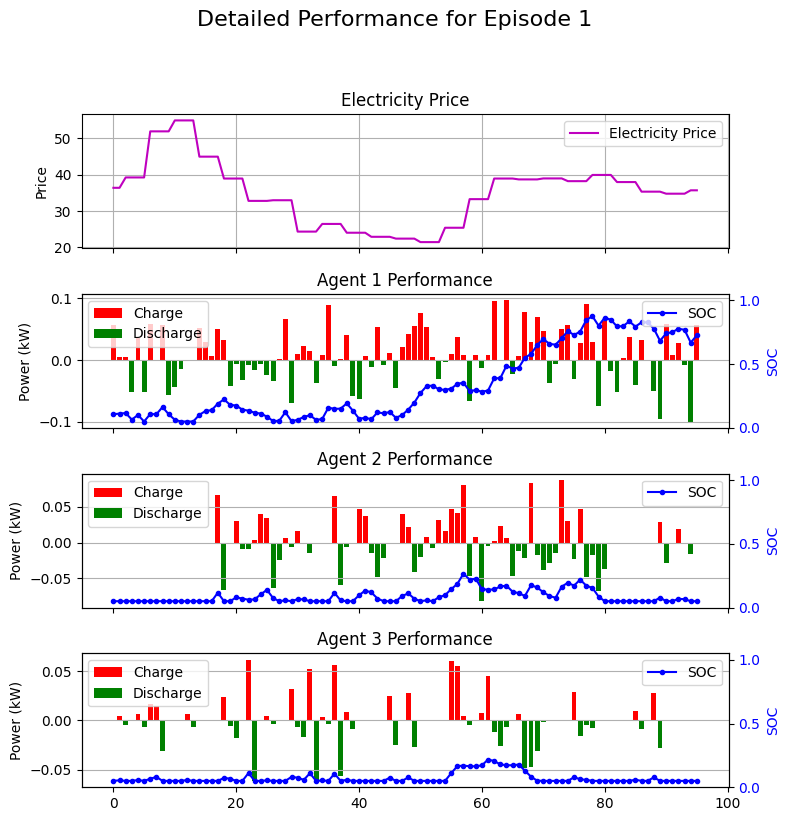

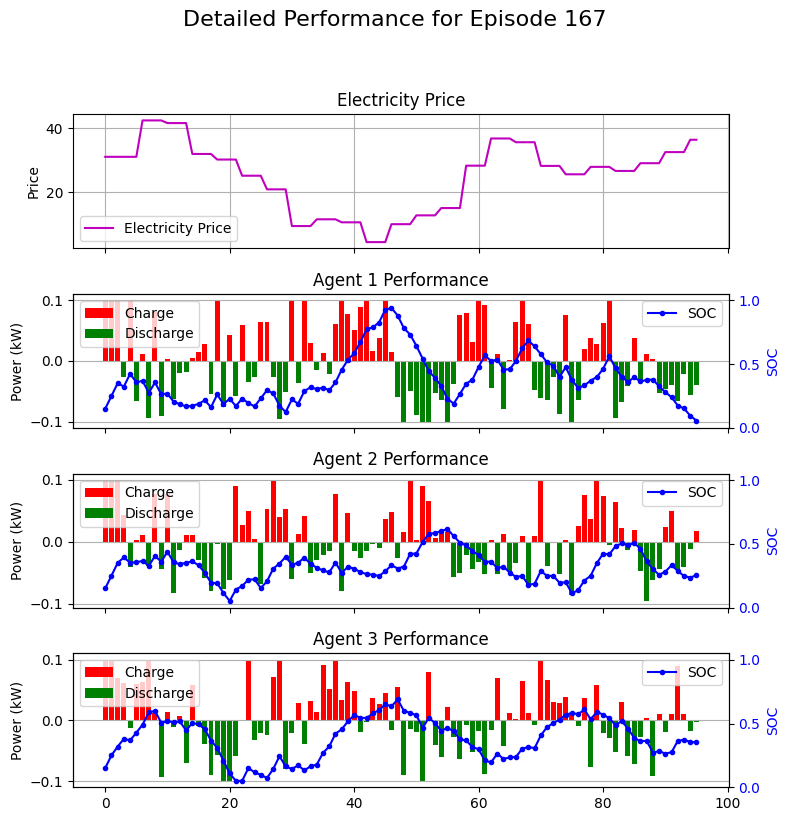

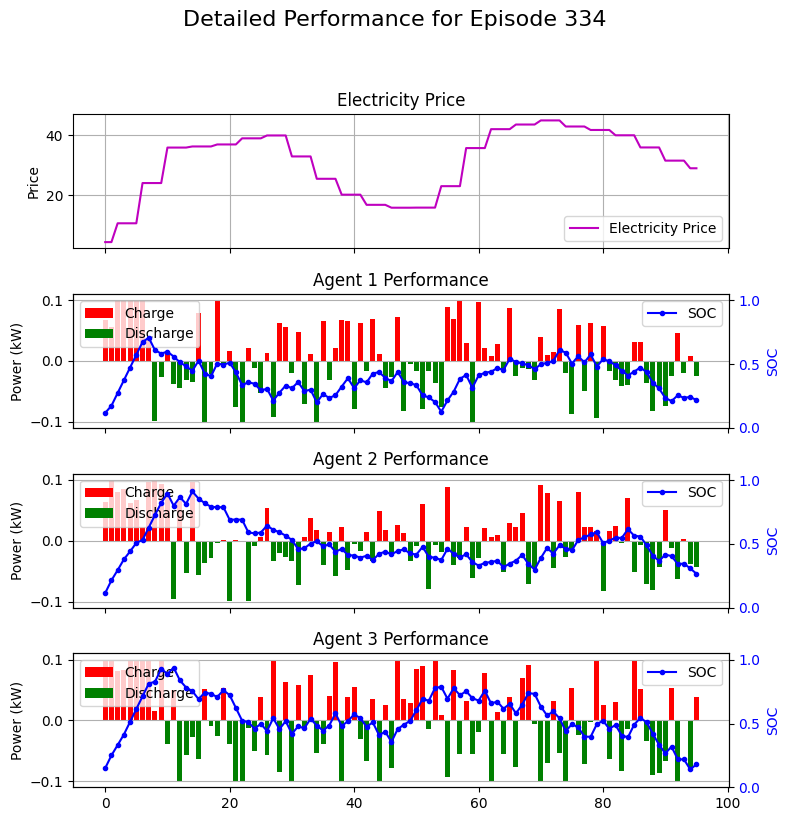

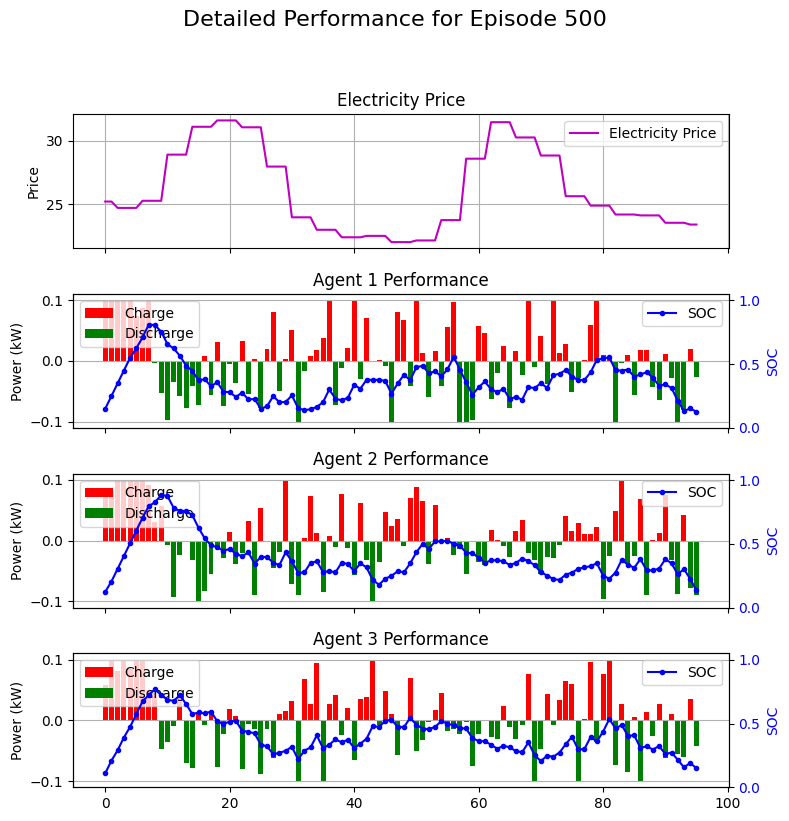

In [6]:
# --- 2. 可视化指定多个训练回合的数据 ---
# ==============================================================
# == 在这里设置你想可视化的回合数列表 (从0开始计数) ==
# == 例如 [0, 9, 99] 会打印第1, 10, 100回合 ==
episodes_to_plot = [0,int(TrainEpisode/3),int(2*TrainEpisode/3),TrainEpisode-1]  # 这里可以修改为你想要查看的回合数列表
# ===============================================================

print(f"\n--- Plotting Detailed Results for Episodes: {[e + 1 for e in episodes_to_plot]} ---")

# 循环遍历需要打印的每一代
for episode_idx in episodes_to_plot:
    if episode_idx >= len(runner.history) or episode_idx < 0:
        print(f"Warning: Episode {episode_idx + 1} not found. Skipping. (Total episodes trained: {len(runner.history)})")
        continue  # 如果指定的回合不存在，则跳过

    # 从历史记录中获取指定回合的数据
    episode_data = runner.history[episode_idx]
    price_history = episode_data['price']
    actions_history = episode_data['actions']
    soc_history = episode_data['soc']

    # 为当前回合创建一个新的图表
    fig, axs = plt.subplots(args.N + 1, 1, figsize=(8, 2 * (args.N + 1)), sharex=True)
    if args.N == 0:
        axs = [axs] # 保证在N=1时axs也是列表

    # 在图表最上方添加总标题
    fig.suptitle(f'Detailed Performance for Episode {episode_idx + 1}', fontsize=16, y=1.02)

    time_steps = np.arange(len(price_history))

    # 绘制电价子图
    ax_price = axs[0]
    ax_price.plot(time_steps, price_history, 'm-', label='Electricity Price')
    ax_price.set_ylabel('Price')
    ax_price.set_title(f'Electricity Price') # 子标题不再需要回合数
    ax_price.legend()
    ax_price.grid(True)

    # 循环绘制每个智能体的子图
    for i in range(args.N):
        ax1 = axs[i + 1]
        
        # 绘制充放电柱状图
        charge_power = np.array(actions_history[i])
        ax1.bar(time_steps, np.maximum(0, charge_power), color='r', width=0.8, label='Charge')
        ax1.bar(time_steps, np.minimum(0, charge_power), color='g', width=0.8, label='Discharge')
        ax1.set_ylabel('Power (kW)', color='k')
        ax1.set_title(f'Agent {i+1} Performance') # 子标题不再需要回合数
        ax1.legend(loc='upper left')
        ax1.grid(True, axis='y')

        # 创建第二个Y轴用于绘制SOC
        ax2 = ax1.twinx()
        ax2.plot(time_steps, soc_history[i][1:], 'b-', marker='.', label='SOC')
        ax2.set_ylabel('SOC', color='b')
        ax2.tick_params(axis='y', labelcolor='b')
        ax2.set_ylim(0, 1.05)
        ax2.legend(loc='upper right')

    # 设置共享的X轴标签并显示图表
    plt.xlabel('Time Step')
    fig.tight_layout(rect=[0, 0, 1, 0.98]) # 调整布局以适应总标题
    plt.show()


--- Plotting Peak-Valley Shaving Results for Episodes: [500] ---


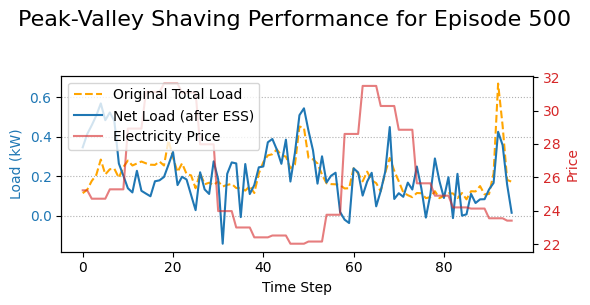

In [7]:
# --- 3. 可视化削峰填谷效果 (训练前后对比) ---
# ===============================================================
# == 在这里设置你想对比的回合 (通常是第一个和最后一个) ==
episodes_to_compare = [TrainEpisode - 1] 
# ===============================================================

print(f"\n--- Plotting Peak-Valley Shaving Results for Episodes: {[e + 1 for e in episodes_to_compare]} ---")

for episode_idx in episodes_to_compare:
    if episode_idx >= len(runner.history) or episode_idx < 0:
        print(f"Warning: Episode {episode_idx + 1} not found. Skipping.")
        continue

    # 从历史记录中获取数据
    episode_data = runner.history[episode_idx]
    price_history = episode_data['price']
    original_load = episode_data['original_load']
    net_load = episode_data['net_load']
    
    time_steps = np.arange(len(price_history))

    # 创建图表和坐标轴
    fig, ax1 = plt.subplots(figsize=(6, 3))
    
    # 设置图表总标题
    fig.suptitle(f'Peak-Valley Shaving Performance for Episode {episode_idx + 1}', fontsize=16, y=1.0)

    # 绘制负荷曲线 (左Y轴)
    color = 'tab:blue'
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Load (kW)', color=color)
    ax1.plot(time_steps, original_load, color='orange', linestyle='--', label='Original Total Load')
    ax1.plot(time_steps, net_load, color=color, linestyle='-', label='Net Load (after ESS)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, axis='y', linestyle=':')
    
    # 创建第二个Y轴用于绘制电价
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Price', color=color)
    ax2.plot(time_steps, price_history, color=color, alpha=0.6, label='Electricity Price')
    ax2.tick_params(axis='y', labelcolor=color)

    # 合并图例
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    fig.tight_layout(rect=[0, 0, 1, 0.96]) # 调整布局以适应总标题
    plt.show()

In [8]:
class TestRunner:
    def __init__(self, args, model_dir, episode_to_load):
        self.args = args
        
        # --- 创建一个用于测试的环境实例 ---
        # 关键是传入测试数据路径和 mode='test'
        env_params = {
            'num_agents': args.num_agents, 
            'episode_length': args.episode_limit,
            'future_price': args.future_price, 
            'battery_capacity': args.battery_capacity,
            'max_charge_rate': args.max_charge_rate, 
            'future_load': args.future_load,
            'w_pv_rolling': 0,  # 测试时通常不关心奖励，设为0
            'data_path': Path.cwd().parent / "data" / "test_prices.csv",
            'mode': 'test'
        }
        self.env = EnergyStorageEnv(**env_params)
        
        # 打印测试环境使用的标准化参数
        print("--- Test Environment Normalization Parameters ---")
        print(f"  Load Mean (from test set): {self.env.load_norm_params['mean']:.4f}")
        print(f"  Load Std (from test set): {self.env.load_norm_params['std']:.4f}")
        print("  (Price normalization is calculated per episode based on the previous day)")
        print("-------------------------------------------------")

        if self.args.algorithm == "MADDPG":
            self.agent_n = [MADDPG(args, agent_id) for agent_id in range(args.N)]
        elif self.args.algorithm == "MATD3":
            self.agent_n = [MATD3(args, agent_id) for agent_id in range(args.N)]
        else:
            raise ValueError(f"Unknown algorithm: {self.args.algorithm}")

        print(f"Loading model for algorithm '{self.args.algorithm}' from episode {episode_to_load}...")
        
        # 构建特定算法的模型路径
        algo_model_dir = os.path.join(model_dir, self.args.algorithm)

        for agent in self.agent_n:
            agent.load_model(algo_model_dir, episode_to_load)
        print(f"Model loaded successfully from {algo_model_dir}.")

    def run_test(self, num_test_episodes):
        all_results = []
        print(f"\n--- Starting Test on {num_test_episodes} Episodes ---")
        
        # 确保测试的回合数不超过可用数据
        num_episodes_to_run = min(num_test_episodes, self.env.num_available_episodes)
        if num_episodes_to_run < num_test_episodes:
            print(f"Warning: Requested {num_test_episodes} episodes, but only {num_episodes_to_run} are available in test data.")

        for ep_idx in range(num_episodes_to_run):
            # 直接调用环境的reset，并传入回合索引。环境内部会处理数据和标准化。
            obs_n = self.env.reset(episode_idx=ep_idx)
            episode_history = defaultdict(list)
            
            for _ in range(self.args.episode_limit):
                # 选择动作时不加噪声
                a_n = [agent.choose_action(obs, noise_std=0.0) for agent, obs in zip(self.agent_n, obs_n)]
                obs_next_n, r_n, done_n, info = self.env.step(copy.deepcopy(a_n))
                
                # 记录该步信息
                for key, value in info.items():
                    episode_history[key].append(value)
                
                obs_n = obs_next_n
                if all(done_n):
                    break
            
            all_results.append(episode_history)
            if (ep_idx + 1) % 10 == 0:
                print(f"  Completed test episode {ep_idx + 1}/{num_episodes_to_run}")
        
        print("--- Test Finished ---")
        return all_results

def analyze_and_plot_test_results(results):
    if not results:
        print("No test results to analyze.")
        return
        
    total_reward, total_original_cost, total_ess_profit = 0, 0, 0
    total_soc_penalty, total_peak_valley_penalty, total_cost_with_ess = 0, 0, 0
    all_original_loads, all_net_loads = [], []

    for episode_result in results:
        ep_ess_profit = np.sum(episode_result['ess_profit'])
        ep_soc_penalty = np.sum(episode_result['soc_penalty'])
        ep_peak_valley_penalty = np.sum(episode_result['peak_valley_penalty'])
        
        total_reward += ep_ess_profit + ep_soc_penalty + ep_peak_valley_penalty
        total_original_cost += np.sum(episode_result['original_load_cost'])
        total_cost_with_ess += np.sum(episode_result['cost_with_ess'])
        total_ess_profit += ep_ess_profit
        total_soc_penalty += ep_soc_penalty
        total_peak_valley_penalty += ep_peak_valley_penalty
        
        all_original_loads.extend(episode_result['original_total_load'])
        all_net_loads.extend(episode_result['net_total_load'])

    std_original_load = np.std(all_original_loads)
    std_net_load = np.std(all_net_loads)
    std_reduction_percentage = ((std_original_load - std_net_load) / std_original_load) * 100 if std_original_load != 0 else 0
    cost_saving_percentage = ((total_original_cost - total_cost_with_ess) / total_original_cost) * 100 if total_original_cost != 0 else 0

    print("\n--- Overall Test Performance Analysis ---")
    print(f"1. Total Reward: {total_reward:,.2f}")
    print(f"2. Original Cost: {total_original_cost:,.2f}")
    print(f"3. ESS Profit: {total_ess_profit:,.2f}")
    print(f"4. SOC Penalty: {total_soc_penalty:,.2f}")
    print(f"5. Peak-Valley Penalty: {total_peak_valley_penalty:,.2f}")
    print("-" * 40)
    print("6. Peak-Valley Shaving Analysis (Standard Deviation of Total Load):")
    print(f"   - Original Load STD: {std_original_load:.2f}")
    print(f"   - Net Load STD (with ESS): {std_net_load:.2f}")
    print(f"   - Fluctuation Reduction: {std_reduction_percentage:.2f}%")
    print("-" * 40)
    print("Summary:")
    print(f"   - Total Cost with ESS: {total_cost_with_ess:,.2f}")
    print(f"   - Total Cost Saving: {total_original_cost - total_cost_with_ess:,.2f}")
    print(f"   - Cost Saving Percentage: {cost_saving_percentage:.2f}%")

# =================================================================
# --- 执行测试 ---
# =================================================================
model_dir_to_load = "./saved_models"
episode_to_load = TrainEpisode

test_runner = TestRunner(args, model_dir=model_dir_to_load, episode_to_load=episode_to_load)

num_test_episodes = 10
test_results = test_runner.run_test(num_test_episodes)

analyze_and_plot_test_results(test_results)

--- Test Environment Normalization Parameters ---
  Load Mean (from test set): 0.1081
  Load Std (from test set): 0.1122
  (Price normalization is calculated per episode based on the previous day)
-------------------------------------------------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
Loading model for algorithm 'MATD3' from episode 500...
Model loaded successfully from ./saved_models\MATD3.

--- Starting Test on 10 Episodes ---


c:\Users\Administrator\Desktop\GithubHome\MADRL_ESS\test\matd3.py:109: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.actor.load_state_dict(torch.load(actor_path))
c:\Us

  Completed test episode 10/10
--- Test Finished ---

--- Overall Test Performance Analysis ---
1. Total Reward: 123.05
2. Original Cost: 11,854.22
3. ESS Profit: 123.05
4. SOC Penalty: 0.00
5. Peak-Valley Penalty: 0.00
----------------------------------------
6. Peak-Valley Shaving Analysis (Standard Deviation of Total Load):
   - Original Load STD: 0.20
   - Net Load STD (with ESS): 0.24
   - Fluctuation Reduction: -19.07%
----------------------------------------
Summary:
   - Total Cost with ESS: 11,731.17
   - Total Cost Saving: 123.05
   - Cost Saving Percentage: 1.04%
